# **Penting**
- Jangan mengubah atau menambahkan cell text yang sudah disediakan, Anda hanya perlu mengerjakan cell code yang sudah disediakan.
- Pastikan seluruh kriteria memiliki output yang sesuai, karena jika tidak ada output dianggap tidak selesai.
- Misal, Anda menggunakan df = df.dropna() silakan gunakan df.isnull().sum() sebagai tanda sudah berhasil. Silakan sesuaikan seluruh output dengan perintah yang sudah disediakan.
- Pastikan Anda melakukan Run All sebelum mengirimkan submission untuk memastikan seluruh cell berjalan dengan baik.
- Pastikan Anda menggunakan variabel df dari awal sampai akhir dan tidak diperbolehkan mengganti nama variabel tersebut.
- Hapus simbol pagar (#) pada kode yang bertipe komentar jika Anda menerapkan kriteria tambahan
- Biarkan simbol pagar (#) jika Anda tidak menerapkan kriteria tambahan
- Pastikan Anda mengerjakan sesuai section yang sudah diberikan tanpa mengubah judul atau header yang disediakan.

# **INFORMASI DATASET**

Dataset ini menyajikan gambaran mendalam mengenai perilaku transaksi dan pola aktivitas keuangan, sehingga sangat ideal untuk eksplorasi **deteksi penipuan (fraud detection)** dan **identifikasi anomali**. Dataset ini mencakup **2.512 sampel data transaksi**, yang mencakup berbagai atribut transaksi, demografi nasabah, dan pola penggunaan.

Setiap entri memberikan wawasan komprehensif terhadap perilaku transaksi, memungkinkan analisis untuk **keamanan finansial** dan pengembangan model prediktif.

## Fitur Utama

- **`TransactionID`**: Pengidentifikasi unik alfanumerik untuk setiap transaksi.  
- **`AccountID`**: ID unik untuk setiap akun, dapat memiliki banyak transaksi.  
- **`TransactionAmount`**: Nilai transaksi dalam mata uang, mulai dari pengeluaran kecil hingga pembelian besar.  
- **`TransactionDate`**: Tanggal dan waktu transaksi terjadi.  
- **`TransactionType`**: Tipe transaksi berupa `'Credit'` atau `'Debit'`.  
- **`Location`**: Lokasi geografis transaksi (nama kota di Amerika Serikat).  
- **`DeviceID`**: ID perangkat yang digunakan dalam transaksi.  
- **`IP Address`**: Alamat IPv4 yang digunakan saat transaksi, dapat berubah untuk beberapa akun.  
- **`MerchantID`**: ID unik merchant, menunjukkan merchant utama dan anomali transaksi.  
- **`AccountBalance`**: Saldo akun setelah transaksi berlangsung.  
- **`PreviousTransactionDate`**: Tanggal transaksi terakhir pada akun, berguna untuk menghitung frekuensi transaksi.  
- **`Channel`**: Kanal transaksi seperti `Online`, `ATM`, atau `Branch`.  
- **`CustomerAge`**: Usia pemilik akun.  
- **`CustomerOccupation`**: Profesi pengguna seperti `Dokter`, `Insinyur`, `Mahasiswa`, atau `Pensiunan`.  
- **`TransactionDuration`**: Lama waktu transaksi (dalam detik).  
- **`LoginAttempts`**: Jumlah upaya login sebelum transaksi—jumlah tinggi bisa mengindikasikan anomali.

Tugas kamu adalah membuat model clustering yang selanjutnya akan digunakan untuk membuat model klasifikasi.


# **1. Import Library**
Pada tahap ini, Anda perlu mengimpor beberapa pustaka (library) Python yang dibutuhkan untuk analisis data dan pembangunan model machine learning. Semua library yang dibutuhkan harus **import** di **cell** ini, jika ada library yang dijalankan di cell lain maka **submission langsung ditolak**

In [1]:
#Type your code here
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import joblib
from yellowbrick.cluster import KElbowVisualizer
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.preprocessing import LabelEncoder
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA
from IPython.display import display

# **2. Memuat Dataset**
Pada tahap ini, Anda perlu memuat dataset ke dalam notebook lalu mengecek informasi dataset sebelum nantinya dilakukan pembersihan. Hal-hal yang perlu dilakukan pada tahapan ini yaitu:
1. **Memahami Struktur Data**
   - Dataset harus mengambil referensi wajib digunakan (bisa dilihat [Disini](https://drive.google.com/drive/folders/1Zs7VmPZ-jNwsRlMKH65Ea-LApSwx6lKx?usp=drive_link))
   - Melakukan loading dataset ke dalam notebook dan menampilkan 5 baris pertama dengan function `head`.
   - Tinjau jumlah baris kolom dan jenis data dalam dataset dengan function `info`.  
   - Menampilkan statistik deskriptif dataset dengan menjalankan `describe`.
   - Pastikan **setiap function tersebut** memiliki **output pada setiap cell** code. Jika tidak **submission langsung ditolak**
   

Gunakan code ini untuk melakukan load data secara otomatis tanpa harus download data tersebut secara manual:
```python
url='https://drive.google.com/uc?id=1gnLO9qvEPqv1uBt1928AcsCmdvzqjC5m'
df = pd.read_csv(url)
```

Penting: pada kriteria pertama hindari penggunaan print() dan display() karena seluruh fungsi yang digunakan sudah memiliki standar output dan menghasilkan output yang diharapkan.

Kriteria 1 akan ditolak ketika:
- print(__.head())
- display(___.head())
dst

Kriteria 1 akan diterima ketika Anda menggunakan fungsi yang diminta tanpa menambahkan deskripsi apapun.

In [2]:
# Load data
url='https://drive.google.com/uc?id=1gnLO9qvEPqv1uBt1928AcsCmdvzqjC5m'
df = pd.read_csv(url)

In [3]:
# Tampilkan 5 baris pertama dengan function head.
df.head()

,TransactionID,AccountID,TransactionAmount,TransactionDate,TransactionType,Location,DeviceID,IP Address,MerchantID,Channel,CustomerAge,CustomerOccupation,TransactionDuration,LoginAttempts,AccountBalance,PreviousTransactionDate
0,TX000001,AC00128,14.09,2023-04-11 16:29:14,Debit,San Diego,D000380,162.198.218.92,M015,ATM,70.0,Doctor,81.0,1.0,5112.21,2024-11-04 08:08:08
1,TX000002,AC00455,376.24,2023-06-27 16:44:19,Debit,Houston,D000051,13.149.61.4,M052,ATM,68.0,Doctor,141.0,1.0,13758.91,2024-11-04 08:09:35
2,TX000003,AC00019,126.29,2023-07-10 18:16:08,Debit,Mesa,D000235,215.97.143.157,M009,Online,19.0,Student,56.0,1.0,1122.35,2024-11-04 08:07:04
3,TX000004,AC00070,184.50,2023-05-05 16:32:11,Debit,Raleigh,D000187,200.13.225.150,M002,Online,26.0,Student,25.0,1.0,8569.06,2024-11-04 08:09:06
4,TX000005,AC00411,13.45,2023-10-16 17:51:24,Credit,Atlanta,D000308,65.164.3.100,M091,Online,NaN,Student,198.0,1.0,7429.40,2024-11-04 08:06:39


In [4]:
# Tinjau jumlah baris kolom dan jenis data dalam dataset dengan info.
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2537 entries, 0 to 2536
Data columns (total 16 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   TransactionID            2508 non-null   object 
 1   AccountID                2516 non-null   object 
 2   TransactionAmount        2511 non-null   float64
 3   TransactionDate          2509 non-null   object 
 4   TransactionType          2507 non-null   object 
 5   Location                 2507 non-null   object 
 6   DeviceID                 2507 non-null   object 
 7   IP Address               2517 non-null   object 
 8   MerchantID               2514 non-null   object 
 9   Channel                  2510 non-null   object 
 10  CustomerAge              2519 non-null   float64
 11  CustomerOccupation       2514 non-null   object 
 12  TransactionDuration      2511 non-null   float64
 13  LoginAttempts            2516 non-null   float64
 14  AccountBalance          

In [5]:
# Menampilkan statistik deskriptif dataset dengan menjalankan describe
df.describe()

,TransactionAmount,CustomerAge,TransactionDuration,LoginAttempts,AccountBalance
count,2511.000000,2519.000000,2511.000000,2516.000000,2510.000000
mean,297.656468,44.678444,119.422939,1.121622,5113.438124
std,292.230367,17.837359,70.078513,0.594469,3897.975861
min,0.260000,18.000000,10.000000,1.000000,101.250000
25%,81.310000,27.000000,63.000000,1.000000,1504.727500
50%,211.360000,45.000000,112.000000,1.000000,4734.110000
75%,413.105000,59.000000,161.000000,1.000000,7672.687500
max,1919.110000,80.000000,300.000000,5.000000,14977.990000


(Opsional) Memuat Dataset dan Melakukan Exploratory Data Analysis (EDA) [Skilled]

**Biarkan kosong jika tidak menerapkan kriteria skilled**

**Apabila ingin menerapkan Advanced, pastikan seluruh visualisasi tidak ada yang overlap**

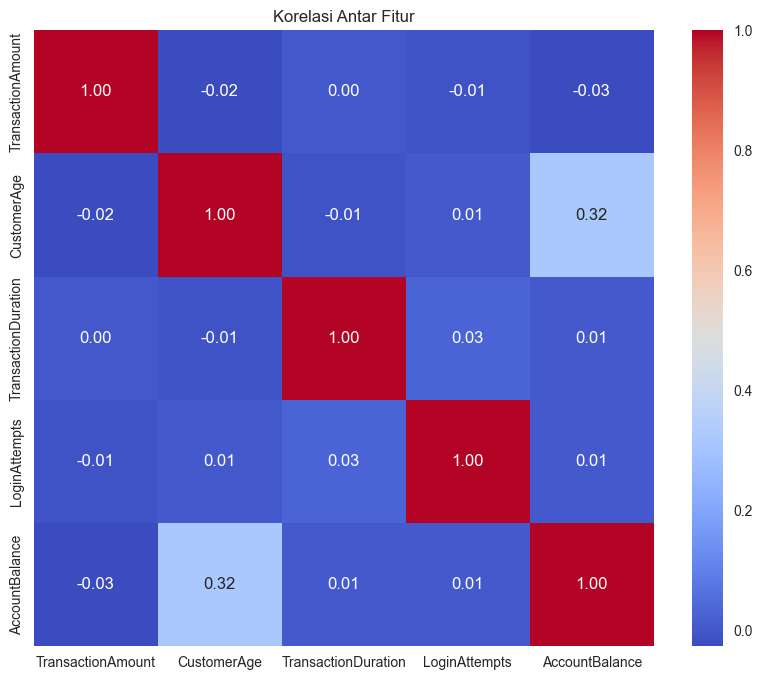

In [6]:
# Menampilkan korelasi antar fitur (Opsional Skilled 1)
corr = df.corr(numeric_only=True)
plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Korelasi Antar Fitur')
plt.show()

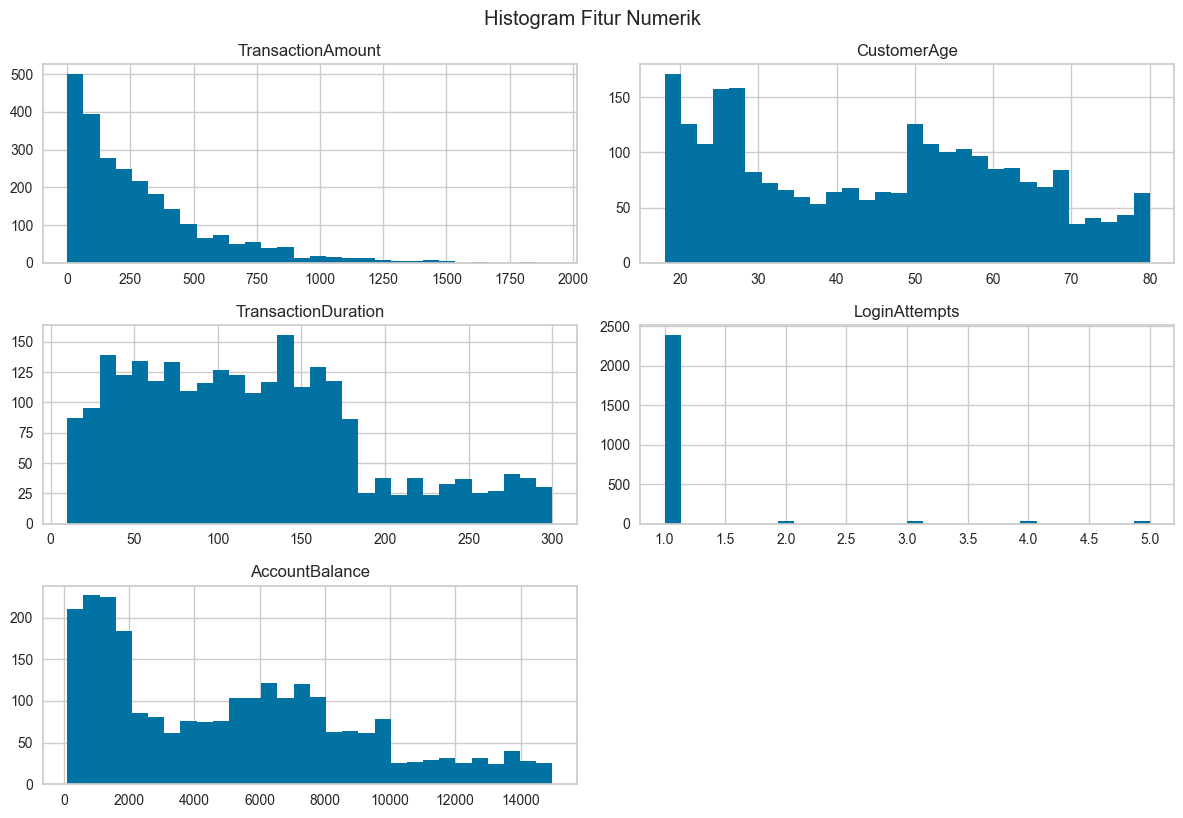

In [7]:
# Menampilkan histogram untuk semua kolom numerik (Opsional Skilled 1)
df.hist(figsize=(12, 8), bins=30)
plt.tight_layout()
plt.suptitle('Histogram Fitur Numerik', y=1.02)
plt.show()

(Opsional) Memuat Dataset dan Melakukan Exploratory Data Analysis (EDA) [Advanced]

**Biarkan kosong jika tidak menerapkan kriteria advanced**

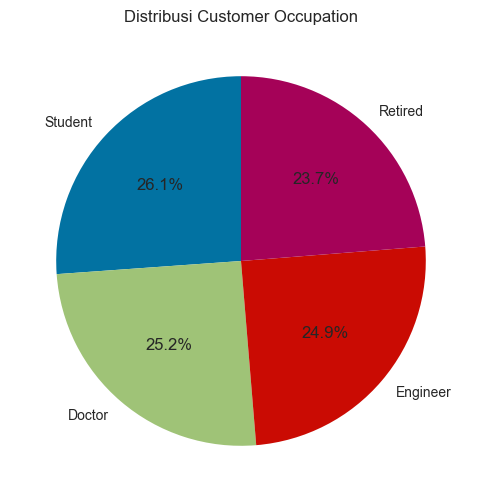

In [8]:
# Visualisasi yang lebih informatif (Opsional Advanced 1)
# Distribusi CustomerOccupation (pie chart)

plt.figure(figsize=(6, 6))
plt.pie(df['CustomerOccupation'].value_counts(), labels=df['CustomerOccupation'].value_counts().index, autopct='%1.1f%%', startangle=90)
plt.title('Distribusi Customer Occupation')
plt.show()

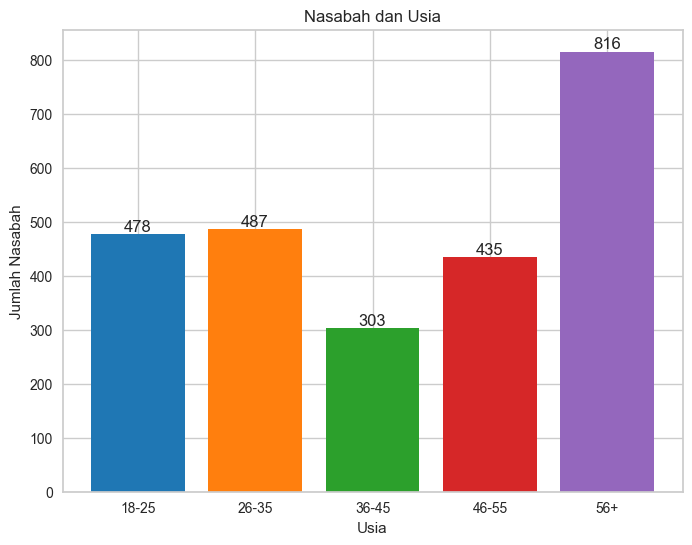

In [9]:
# Distribusi Usia (Binning + Bar Chart)
age18_25 = df.CustomerAge[(df.CustomerAge >= 18) & (df.CustomerAge <= 25)]
age26_35 = df.CustomerAge[(df.CustomerAge >= 26) & (df.CustomerAge <= 35)]
age36_45 = df.CustomerAge[(df.CustomerAge >= 36) & (df.CustomerAge <= 45)]
age46_55 = df.CustomerAge[(df.CustomerAge >= 46) & (df.CustomerAge <= 55)]
age56_above = df.CustomerAge[df.CustomerAge >= 56]

# Menyusun data untuk plotting
x = ['18-25', '26-35', '36-45', '46-55', '56+']
y = [len(age18_25.values), len(age26_35.values), len(age36_45.values),
     len(age46_55.values), len(age56_above.values)]

# Membuat bar chart untuk distribusi usia nasabah
plt.figure(figsize=(8, 6))
plt.title("Nasabah dan Usia")
plt.xlabel('Usia')
plt.ylabel('Jumlah Nasabah')
colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd']
bars = plt.bar(x, y, color=colors)

# Label di atas bar

for bar in bars:
    plt.text(bar.get_x() + bar.get_width() / 2,
             bar.get_height(), str(int(bar.get_height())),
             ha='center', va='bottom')

plt.show()

# **3. Pembersihan dan Pra Pemrosesan Data**

Pada tahap ini, Anda akan melakukan **Pembersihan Dataset** untuk menjadikan dataset mudah diintepretasi dan bisa dilatih. Hal-hal yang wajib kamu lakukan yaitu:

1. **Mengecek dataset** menggunakan isnull().sum() dan duplicated().sum().
2. Melakukan feature scaling menggunakan `MinMaxScaler()` atau `StandardScalar()` untuk fitur numerik.
3. Melakukan feature encoding menggunakan `LabelEncoder()` untuk fitur kategorikal.
4. Melakukan drop pada kolom id.
5. **Ketentuan Cell Code**
   - Pastikan **setiap pemeriksaan tersebut** memiliki **output pada cell-nya**. Jika tidak **submission langsung ditolak**


In [10]:
# Mengecek dataset menggunakan isnull().sum()
# Mengecek jumlah missing value per kolom
print("Jumlah missing value tiap kolom:\n")
print(df.isnull().sum())
(df[df.isnull().any(axis=1)].head())

Jumlah missing value tiap kolom:

TransactionID              29
AccountID                  21
TransactionAmount          26
TransactionDate            28
TransactionType            30
Location                   30
DeviceID                   30
IP Address                 20
MerchantID                 23
Channel                    27
CustomerAge                18
CustomerOccupation         23
TransactionDuration        26
LoginAttempts              21
AccountBalance             27
PreviousTransactionDate    24
dtype: int64


,TransactionID,AccountID,TransactionAmount,TransactionDate,TransactionType,Location,DeviceID,IP Address,MerchantID,Channel,CustomerAge,CustomerOccupation,TransactionDuration,LoginAttempts,AccountBalance,PreviousTransactionDate
4,TX000005,AC00411,13.45,2023-10-16 17:51:24,Credit,Atlanta,D000308,65.164.3.100,M091,Online,NaN,Student,198.0,1.0,7429.40,2024-11-04 08:06:39
22,TX000023,AC00095,52.20,2023-06-06 18:54:15,Debit,Atlanta,NaN,133.63.96.21,M022,Online,39.0,Engineer,120.0,1.0,8974.93,2024-11-04 08:07:01
37,TX000038,AC00202,649.28,2023-03-02 17:53:32,Debit,San Jose,D000448,73.108.76.238,M074,ATM,75.0,Retired,137.0,NaN,4875.86,2024-11-04 08:11:15
45,NaN,AC00401,435.27,2023-10-04 17:49:29,Debit,Chicago,D000297,197.162.55.147,M051,Branch,74.0,Retired,90.0,1.0,4673.28,2024-11-04 08:11:12
49,TX000050,AC00471,22.01,2023-03-27 16:45:18,Credit,Sacramento,NaN,124.6.134.78,M055,Online,41.0,Engineer,175.0,1.0,1335.09,2024-11-04 08:06:31


In [11]:
# Mengecek dataset menggunakan duplicated().sum()

df.duplicated().sum()
(df[df.duplicated()].head())

,TransactionID,AccountID,TransactionAmount,TransactionDate,TransactionType,Location,DeviceID,IP Address,MerchantID,Channel,CustomerAge,CustomerOccupation,TransactionDuration,LoginAttempts,AccountBalance,PreviousTransactionDate
2512,TX001748,AC00305,506.90,2023-11-01 17:44:46,Credit,Houston,D000337,138.210.196.19,M038,Branch,64.0,Doctor,56.0,1.0,11471.87,2024-11-04 08:10:09
2514,TX000147,AC00385,973.39,2023-08-30 17:23:20,Debit,Sacramento,D000292,202.194.199.70,M026,Branch,77.0,Retired,296.0,1.0,2042.22,2024-11-04 08:11:44
2515,TX001348,AC00455,787.41,2023-06-19 16:22:28,Debit,Memphis,D000351,150.25.200.56,M081,Online,25.0,Student,39.0,1.0,300.87,2024-11-04 08:06:44
2516,TX000986,AC00278,121.17,2023-12-25 17:31:16,Debit,Phoenix,D000573,155.19.119.0,M053,ATM,68.0,Doctor,158.0,1.0,12990.77,2024-11-04 08:10:12
2517,TX002364,AC00327,21.90,2023-04-10 17:04:28,Debit,Phoenix,D000216,136.172.149.77,M084,ATM,28.0,Student,30.0,1.0,1052.27,2024-11-04 08:11:15


In [12]:
# Melakukan feature scaling menggunakan MinMaxScaler() atau StandardScalar() untuk fitur numerik.
# Pastikan kamu menggunakan function head setelah melalukan scaling.

# Simpan dataframe asli untuk backup
df_original = df.copy()

# ambil fitur numerik dari df
numerical_cols = df.select_dtypes(include=['int64','float64']).columns

# Min-Max Scaling untuk semua numerik
min_max_scaler = MinMaxScaler()
df_minmax = df.copy()
df_minmax[numerical_cols] = min_max_scaler.fit_transform(df[numerical_cols])

# Update df utama dengan hasil scaling
df = df_minmax.copy()

print("Hasil Min-Max Scaling:")
print("Data sudah di-scale, df utama telah diupdate")
df_minmax.copy().head()

Hasil Min-Max Scaling:
Data sudah di-scale, df utama telah diupdate


,TransactionID,AccountID,TransactionAmount,TransactionDate,TransactionType,Location,DeviceID,IP Address,MerchantID,Channel,CustomerAge,CustomerOccupation,TransactionDuration,LoginAttempts,AccountBalance,PreviousTransactionDate
0,TX000001,AC00128,0.007207,2023-04-11 16:29:14,Debit,San Diego,D000380,162.198.218.92,M015,ATM,0.838710,Doctor,0.244828,0.0,0.336832,2024-11-04 08:08:08
1,TX000002,AC00455,0.195940,2023-06-27 16:44:19,Debit,Houston,D000051,13.149.61.4,M052,ATM,0.806452,Doctor,0.451724,0.0,0.918055,2024-11-04 08:09:35
2,TX000003,AC00019,0.065680,2023-07-10 18:16:08,Debit,Mesa,D000235,215.97.143.157,M009,Online,0.016129,Student,0.158621,0.0,0.068637,2024-11-04 08:07:04
3,TX000004,AC00070,0.096016,2023-05-05 16:32:11,Debit,Raleigh,D000187,200.13.225.150,M002,Online,0.129032,Student,0.051724,0.0,0.569198,2024-11-04 08:09:06
4,TX000005,AC00411,0.006874,2023-10-16 17:51:24,Credit,Atlanta,D000308,65.164.3.100,M091,Online,NaN,Student,0.648276,0.0,0.492591,2024-11-04 08:06:39


In [13]:
# Melakukan drop pada kolom yang memiliki keterangan id dan IP Address
id_columns = ['TransactionID', 'AccountID', 'DeviceID', 'IP Address', 'MerchantID']
existing_id_columns = [col for col in id_columns if col in df.columns]

if existing_id_columns:
   print(f"Kolom-kolom yang akan dihapus: {existing_id_columns}")
   df = df.drop(existing_id_columns, axis=1)
else:
  print("\nTidak ada kolom yang digunakan, kemungkinan sudah terhapus")

print(f"\nFinal dataframe shape: {df.shape}")
df.head()


Kolom-kolom yang akan dihapus: ['TransactionID', 'AccountID', 'DeviceID', 'IP Address', 'MerchantID']

Final dataframe shape: (2537, 11)


,TransactionAmount,TransactionDate,TransactionType,Location,Channel,CustomerAge,CustomerOccupation,TransactionDuration,LoginAttempts,AccountBalance,PreviousTransactionDate
0,0.007207,2023-04-11 16:29:14,Debit,San Diego,ATM,0.838710,Doctor,0.244828,0.0,0.336832,2024-11-04 08:08:08
1,0.195940,2023-06-27 16:44:19,Debit,Houston,ATM,0.806452,Doctor,0.451724,0.0,0.918055,2024-11-04 08:09:35
2,0.065680,2023-07-10 18:16:08,Debit,Mesa,Online,0.016129,Student,0.158621,0.0,0.068637,2024-11-04 08:07:04
3,0.096016,2023-05-05 16:32:11,Debit,Raleigh,Online,0.129032,Student,0.051724,0.0,0.569198,2024-11-04 08:09:06
4,0.006874,2023-10-16 17:51:24,Credit,Atlanta,Online,NaN,Student,0.648276,0.0,0.492591,2024-11-04 08:06:39


In [14]:
# Melakukan feature encoding menggunakan LabelEncoder() untuk fitur kategorikal.
# Pastikan kamu menggunakan function head setelah melalukan encoding.

# inisialisasi dictionary encoder
encoders = {}

# daftar kolom kate
categorical_cols = ['TransactionType', 'Location', 'CustomerOccupation', 'Channel']

# lakukan encoding per kolom
for col in categorical_cols:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])
    encoders[col] = le

df.head()

,TransactionAmount,TransactionDate,TransactionType,Location,Channel,CustomerAge,CustomerOccupation,TransactionDuration,LoginAttempts,AccountBalance,PreviousTransactionDate
0,0.007207,2023-04-11 16:29:14,1,36,0,0.838710,0,0.244828,0.0,0.336832,2024-11-04 08:08:08
1,0.195940,2023-06-27 16:44:19,1,15,0,0.806452,0,0.451724,0.0,0.918055,2024-11-04 08:09:35
2,0.065680,2023-07-10 18:16:08,1,23,2,0.016129,3,0.158621,0.0,0.068637,2024-11-04 08:07:04
3,0.096016,2023-05-05 16:32:11,1,33,2,0.129032,3,0.051724,0.0,0.569198,2024-11-04 08:09:06
4,0.006874,2023-10-16 17:51:24,0,1,2,NaN,3,0.648276,0.0,0.492591,2024-11-04 08:06:39


In [15]:
# Last checking gunakan columns.tolist() untuk checking seluruh fitur yang ada.
# Perbaiki kode di bawah ini tanpa menambahkan atau mengurangi cell code ini.

df.columns.tolist()
df.head()

,TransactionAmount,TransactionDate,TransactionType,Location,Channel,CustomerAge,CustomerOccupation,TransactionDuration,LoginAttempts,AccountBalance,PreviousTransactionDate
0,0.007207,2023-04-11 16:29:14,1,36,0,0.838710,0,0.244828,0.0,0.336832,2024-11-04 08:08:08
1,0.195940,2023-06-27 16:44:19,1,15,0,0.806452,0,0.451724,0.0,0.918055,2024-11-04 08:09:35
2,0.065680,2023-07-10 18:16:08,1,23,2,0.016129,3,0.158621,0.0,0.068637,2024-11-04 08:07:04
3,0.096016,2023-05-05 16:32:11,1,33,2,0.129032,3,0.051724,0.0,0.569198,2024-11-04 08:09:06
4,0.006874,2023-10-16 17:51:24,0,1,2,NaN,3,0.648276,0.0,0.492591,2024-11-04 08:06:39


(Opsional) Pembersihan dan Pra Pemrosesan Data [Skilled]

**Biarkan kosong jika tidak menerapkan kriteria skilled**

In [16]:
# Menangani data yang hilang (bisa menggunakan dropna() atau metode imputasi fillna()).

# kalau numerik → isi dengan mean
for col in df.select_dtypes(include=['int64', 'float64']).columns:
    df[col] = df[col].fillna(df[col].mean())

# kalau kategorikal → isi dengan modus
for col in df.select_dtypes(include=['object']).columns:
    df[col] = df[col].fillna(df[col].mode()[0])

print("Jumlah missing value setelah imputasi:")
print(df.isnull().sum())
df.head()

Jumlah missing value setelah imputasi:
TransactionAmount          0
TransactionDate            0
TransactionType            0
Location                   0
Channel                    0
CustomerAge                0
CustomerOccupation         0
TransactionDuration        0
LoginAttempts              0
AccountBalance             0
PreviousTransactionDate    0
dtype: int64


,TransactionAmount,TransactionDate,TransactionType,Location,Channel,CustomerAge,CustomerOccupation,TransactionDuration,LoginAttempts,AccountBalance,PreviousTransactionDate
0,0.007207,2023-04-11 16:29:14,1,36,0,0.838710,0,0.244828,0.0,0.336832,2024-11-04 08:08:08
1,0.195940,2023-06-27 16:44:19,1,15,0,0.806452,0,0.451724,0.0,0.918055,2024-11-04 08:09:35
2,0.065680,2023-07-10 18:16:08,1,23,2,0.016129,3,0.158621,0.0,0.068637,2024-11-04 08:07:04
3,0.096016,2023-05-05 16:32:11,1,33,2,0.129032,3,0.051724,0.0,0.569198,2024-11-04 08:09:06
4,0.006874,2023-10-16 17:51:24,0,1,2,0.430297,3,0.648276,0.0,0.492591,2024-11-04 08:06:39


In [17]:
# Menghapus data duplikat menggunakan drop_duplicates().

# sebelum hapus duplikat
print("Jumlah data duplikat sebelum dihapus:", df.duplicated().sum())
print("Jumlah baris sebelum drop_duplicates:", df.shape[0])

# hapus duplikat
df = df.drop_duplicates()

# setelah hapus duplikat
print("Jumlah data duplikat setelah dihapus:", df.duplicated().sum())
print("Jumlah baris setelah drop_duplicates:", df.shape[0])
df.head()

Jumlah data duplikat sebelum dihapus: 22
Jumlah baris sebelum drop_duplicates: 2537


Jumlah data duplikat setelah dihapus: 0
Jumlah baris setelah drop_duplicates: 2515


,TransactionAmount,TransactionDate,TransactionType,Location,Channel,CustomerAge,CustomerOccupation,TransactionDuration,LoginAttempts,AccountBalance,PreviousTransactionDate
0,0.007207,2023-04-11 16:29:14,1,36,0,0.838710,0,0.244828,0.0,0.336832,2024-11-04 08:08:08
1,0.195940,2023-06-27 16:44:19,1,15,0,0.806452,0,0.451724,0.0,0.918055,2024-11-04 08:09:35
2,0.065680,2023-07-10 18:16:08,1,23,2,0.016129,3,0.158621,0.0,0.068637,2024-11-04 08:07:04
3,0.096016,2023-05-05 16:32:11,1,33,2,0.129032,3,0.051724,0.0,0.569198,2024-11-04 08:09:06
4,0.006874,2023-10-16 17:51:24,0,1,2,0.430297,3,0.648276,0.0,0.492591,2024-11-04 08:06:39


(Opsional) Pembersihan dan Pra Pemrosesan Data [Advanced]

**Biarkan kosong jika tidak menerapkan kriteria advanced**

In [18]:
# Melakukan Handling Outlier Data berdasarkan jumlah outlier, apakah menggunakan metode drop atau mengisi nilai tersebut.

numerical_cols = ['TransactionAmount', 'CustomerAge', 'TransactionDuration', 'LoginAttempts', 'AccountBalance']
total_outliers_before = 0
total_outliers_after = 0

for col in numerical_cols:
    # ambil nilai kuartil 1 (25%) dan kuartil 3 (75%)
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    # hitung IQR (interquartile range)
    IQR = Q3 - Q1
    # hitung batas bawah dan atas
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    # hitung outliers sebelum imputasi
    outliers_before = df[(df[col] < lower_bound) | (df[col] > upper_bound)]
    outliers_count_before = len(outliers_before)
    total_outliers_before += outliers_count_before
    print(f"Kolom {col} - Total outliers sebelum imputasi: {outliers_count_before}")

    if outliers_count_before > 0:
        # hitung median
        median = df[col].median()
        # ganti outlier dengan median
        df[col] = np.where((df[col] < lower_bound) | (df[col] > upper_bound), median, df[col])

        # hitung outliers setelah imputasi
        outliers_after = df[(df[col] < lower_bound) | (df[col] > upper_bound)]
        outliers_count_after = len(outliers_after)
        total_outliers_after += outliers_count_after
        print(f"Kolom {col} - Total outliers setelah imputasi: {outliers_count_after}")

print(f"\nTotal outliers sebelum imputasi (semua kolom): {total_outliers_before}")
print(f"Total outliers setelah imputasi (semua kolom): {total_outliers_after}")

df.head()


Kolom TransactionAmount - Total outliers sebelum imputasi: 113
Kolom TransactionAmount - Total outliers setelah imputasi: 0
Kolom CustomerAge - Total outliers sebelum imputasi: 0
Kolom TransactionDuration - Total outliers sebelum imputasi: 0
Kolom LoginAttempts - Total outliers sebelum imputasi: 141
Kolom LoginAttempts - Total outliers setelah imputasi: 0
Kolom AccountBalance - Total outliers sebelum imputasi: 0

Total outliers sebelum imputasi (semua kolom): 254
Total outliers setelah imputasi (semua kolom): 0


,TransactionAmount,TransactionDate,TransactionType,Location,Channel,CustomerAge,CustomerOccupation,TransactionDuration,LoginAttempts,AccountBalance,PreviousTransactionDate
0,0.007207,2023-04-11 16:29:14,1,36,0,0.838710,0,0.244828,0.0,0.336832,2024-11-04 08:08:08
1,0.195940,2023-06-27 16:44:19,1,15,0,0.806452,0,0.451724,0.0,0.918055,2024-11-04 08:09:35
2,0.065680,2023-07-10 18:16:08,1,23,2,0.016129,3,0.158621,0.0,0.068637,2024-11-04 08:07:04
3,0.096016,2023-05-05 16:32:11,1,33,2,0.129032,3,0.051724,0.0,0.569198,2024-11-04 08:09:06
4,0.006874,2023-10-16 17:51:24,0,1,2,0.430297,3,0.648276,0.0,0.492591,2024-11-04 08:06:39


In [19]:
# Melakukan binning data berdasarkan kondisi rentang nilai pada fitur numerik,
# lakukan pada satu sampai dua fitur numerik.
# Silahkan lakukan encode hasil binning tersebut menggunakan LabelEncoder.
# Pastikan kamu mengerjakan tahapan ini pada satu cell.

# binning dengan quantile (5 kategori)
df['TransactionAmount_bin'] = pd.qcut(df['TransactionAmount'], q=5, labels=False)
df['CustomerAge_bin'] = pd.qcut(df['CustomerAge'], q=5, labels=False)

# encode hasil bining
le = LabelEncoder()
df['TransactionAmount_bin'] = le.fit_transform(df['TransactionAmount_bin'])
df['CustomerAge_bin'] = le.fit_transform(df['CustomerAge_bin'])

df.head()

,TransactionAmount,TransactionDate,TransactionType,Location,Channel,CustomerAge,CustomerOccupation,TransactionDuration,LoginAttempts,AccountBalance,PreviousTransactionDate,TransactionAmount_bin,CustomerAge_bin
0,0.007207,2023-04-11 16:29:14,1,36,0,0.838710,0,0.244828,0.0,0.336832,2024-11-04 08:08:08,0,4
1,0.195940,2023-06-27 16:44:19,1,15,0,0.806452,0,0.451724,0.0,0.918055,2024-11-04 08:09:35,3,4
2,0.065680,2023-07-10 18:16:08,1,23,2,0.016129,3,0.158621,0.0,0.068637,2024-11-04 08:07:04,1,0
3,0.096016,2023-05-05 16:32:11,1,33,2,0.129032,3,0.051724,0.0,0.569198,2024-11-04 08:09:06,2,0
4,0.006874,2023-10-16 17:51:24,0,1,2,0.430297,3,0.648276,0.0,0.492591,2024-11-04 08:06:39,0,2


# **4. Membangun Model Clustering**
Pada tahap ini, Anda membangun model clustering dengan memilih algoritma yang sesuai untuk mengelompokkan data berdasarkan kesamaan.
1. Pastikan Anda menggunakan dataframe yang sudah melalui processing sesuai dengan levelnya (Basic, Skilled, Advanced)
2. Melakukan visualisasi Elbow Method untuk menentukan jumlah cluster terbaik menggunakan `KElbowVisualizer()`.
3. Menggunakan algoritma K-Means Clustering dengan `sklearn.cluster.KMeans()`.
4. Jalankan cell code `joblib.dump(model_kmeans, "model_clustering.h5")` untuk menyimpan model yang sudah dibuat.

In [20]:
# Gunakan describe untuk memastikan proses clustering menggunakan dataset hasil preprocessing
# Lengkapi kode ini dengan mengubah nama DataFrame yang akan dilatih.
# Kode harus digunakan dan dilarang menambahkan syntax lainnya pada cell ini.

df.describe()

,TransactionAmount,TransactionType,Location,Channel,CustomerAge,CustomerOccupation,TransactionDuration,LoginAttempts,AccountBalance,TransactionAmount_bin,CustomerAge_bin
count,2515.000000,2515.000000,2515.000000,2515.000000,2515.000000,2515.000000,2515.000000,2515.0,2515.000000,2515.000000,2515.000000
mean,0.132005,0.788072,21.286282,1.010736,0.429579,1.530417,0.377697,0.0,0.337132,2.000000,1.948310
std,0.109969,0.436975,12.395592,0.830674,0.286277,1.150287,0.240111,0.0,0.260618,1.414495,1.425598
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.000000
25%,0.043180,1.000000,11.000000,0.000000,0.145161,0.500000,0.182759,0.0,0.095324,1.000000,1.000000
50%,0.111087,1.000000,21.000000,1.000000,0.435484,2.000000,0.358621,0.0,0.318555,2.000000,2.000000
75%,0.187258,1.000000,32.000000,2.000000,0.661290,3.000000,0.520690,0.0,0.506842,3.000000,3.000000
max,0.467223,2.000000,43.000000,3.000000,1.000000,4.000000,1.000000,0.0,1.000000,4.000000,4.000000


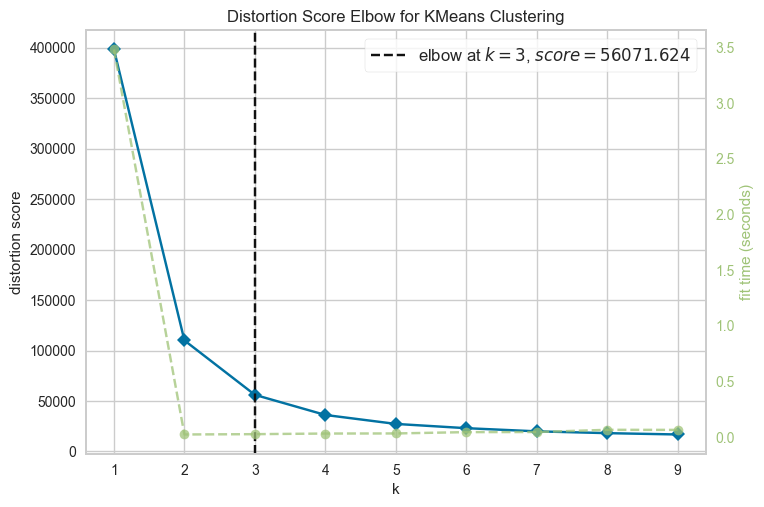

<Axes: title={'center': 'Distortion Score Elbow for KMeans Clustering'}, xlabel='k', ylabel='distortion score'>

In [21]:
# Melakukan visualisasi Elbow Method menggunakan KElbowVisualizer()

features = ['TransactionAmount', 'TransactionDuration', 'LoginAttempts', 'Channel',
            'Location', 'TransactionAmount_bin', 'CustomerAge_bin']

df_dropna = df.dropna()
X = df_dropna[features]

kmeans = KMeans(random_state=42, n_init=10)
visualizer = KElbowVisualizer(kmeans, k=(1, 10))
visualizer.fit(X)
visualizer.show()

In [22]:
# Menggunakan algoritma K-Means Clustering

# inisialisasi dan fit KMeans
kmeans = KMeans(n_clusters=3, random_state=42)
labels = kmeans.fit_predict(X)

# gabungkan label cluster ke data hasil preprocessing
df_clustered = X.copy()
df_clustered['Cluster'] = labels

# tampilkan hasil clustering
df_clustered.head()

,TransactionAmount,TransactionDuration,LoginAttempts,Channel,Location,TransactionAmount_bin,CustomerAge_bin,Cluster
0,0.007207,0.244828,0.0,0,36,0,4,1
1,0.195940,0.451724,0.0,0,15,3,4,0
2,0.065680,0.158621,0.0,2,23,1,0,0
3,0.096016,0.051724,0.0,2,33,2,0,1
4,0.006874,0.648276,0.0,2,1,0,2,2


Jalankan cell code ini untuk menyimpan model kamu.

In [23]:
# Menyimpan model menggunakan joblib
# import joblib
# joblib.dump(___, "model_clustering.h5")

import joblib
joblib.dump(kmeans, "model_clustering.h5")

['model_clustering.h5']

(Opsional) Membangun Model Clustering [Skilled]

**Biarkan kosong jika tidak menerapkan kriteria skilled**

In [24]:
# Menghitung dan menampilkan nilai Silhouette Score.

score = silhouette_score(X, labels)
print("Silhouette Score:", score)

Silhouette Score: 0.5120255830564301


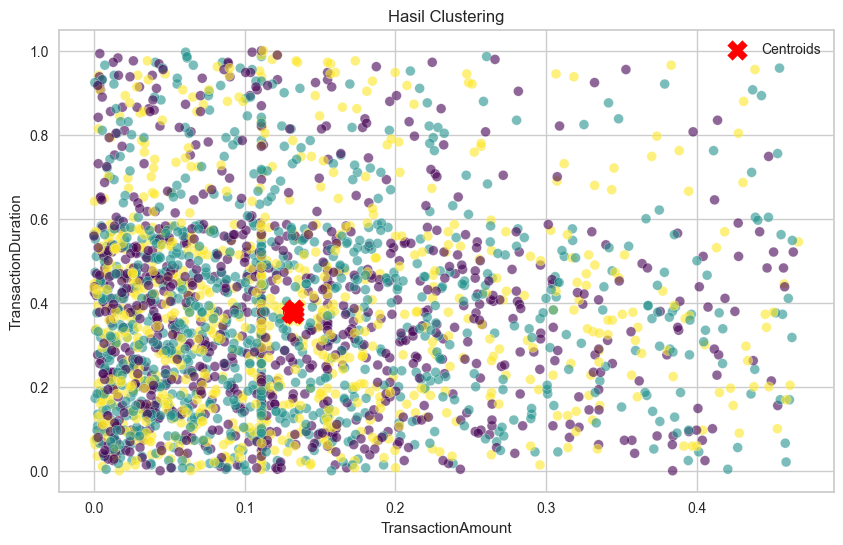

In [25]:
# Membuat visualisasi hasil clustering

# ambil label dan centroid
labels = kmeans.labels_
centroids = kmeans.cluster_centers_

# visualisasi cluster
plt.figure(figsize=(10, 6))
plt.scatter(X.iloc[:, 0], X.iloc[:, 1], c=labels, cmap='viridis',
            s=50, alpha=0.6, edgecolors='w')

# plot centroid
plt.scatter(centroids[:, 0], centroids[:, 1], c='red', marker='X',
            s=200, label='Centroids')

for i, c in enumerate(centroids):
    plt.text(c[0], c[1], f'C{i+1}', color='red', fontsize=12,
             ha='center', va='center')

plt.xlabel(X.columns[0])
plt.ylabel(X.columns[1])
plt.title('Hasil Clustering')
plt.legend()
plt.show()

(Opsional) Membangun Model Clustering [Advanced]

**Biarkan kosong jika tidak menerapkan kriteria advanced**

In [26]:
# Membangun model menggunakan PCA.
pca_model = PCA(n_components=2)
pca_transformed = pca_model.fit_transform(X)

# ___ =PCA(n_components=<x>)
pca_model = PCA(n_components=2)

# ___ = ____.fit_transform(___)
pca_transformed = pca_model.fit_transform(X)

# Menyimpan data PCA sebagai Dataframe dengan nama PCA_<numbers>
# <data_final> = pd.DataFrame(___, columns=['PCA1', 'PCA2', <sesuaikan dengan jumlah n>])
PCA_data = pd.DataFrame(pca_transformed, columns=['PCA1', 'PCA2'])
PCA_data.head()

# Pastikan kamu membangun model Kmeans baru dengan data yang sudah dimodifikasi melalui PCA.
# ___ = KMeans(n_clusters=<x>)
# ___.fit(<data_final>)
kmeans_pca = KMeans(n_clusters=3, random_state=42)
kmeans_pca.fit(PCA_data)

# Menambahkan label cluster ke data PCA
PCA_data['Cluster'] = kmeans_pca.labels_
PCA_data.head()

,PCA1,PCA2,Cluster
0,14.704368,2.888296,2
1,-6.292257,1.050159,0
2,1.719427,-0.980658,0
3,11.720508,-1.536772,2
4,-20.288056,1.153258,1


In [27]:
# Simpan model PCA sebagai perbandingan dengan menjalankan cell code ini joblib.dump(model,"PCA_model_clustering.h5")
# Pastikan yang disimpan model yang sudah melalui .fit berdasarkan dataset yang sudah dilakukan PCA
# joblib.dump(___, "PCA_model_clustering.h5")

joblib.dump(pca_model, "PCA_model_clustering.h5")

['PCA_model_clustering.h5']

# **5. Interpretasi Cluster**

## **a. Interpretasi Hasil Clustering**
1. **Contoh Interpretasi:**
- **Cluster 1: (Nasabah Bertransaksi dan Pendapatan Besar)**:
  - **Rata-rata (mean) Annual Income:** 0.953 (48,260)
  - **Rata-rata (mean) Spending Score:** 0.8 (56.48)
  - **Analisis:** Cluster ini mencakup pelanggan dengan pendapatan tahunan tinggi dan tingkat pengeluaran yang cukup tinggi. Pelanggan dalam cluster ini cenderung memiliki daya beli yang tinggi dan mereka lebih cenderung untuk membelanjakan sebagian besar pendapatan mereka. Sehingga rekomendasi pada kelompok nasabah ini adalah dengan menawarkan produk-produk investasi atau perbankan yang berkualitas tinggi.


In [28]:
# Menampilkan analisis deskriptif minimal mean, min dan max untuk fitur numerik.
# Silakan menambahkan fungsi agregasi lainnya untuk experience lebih baik.
# pastikan output menghasilkan agregasi dan groupby bersamaan dengan mean, min, dan max.

# fitur numerik yang akan dianalisis
numerical_cols = ['TransactionAmount', 'TransactionDuration', 'LoginAttempts',
                  'TransactionAmount_bin', 'CustomerAge_bin']

# grouping berdasarkan tipe transaksi
agg_funcs = ['mean', 'min', 'max', 'median', 'std', 'sum', 'count', 'var']
agg_result = df.groupby('TransactionType')[numerical_cols].agg(agg_funcs)

# loop tiap cluster/grup
for cluster_id, row in agg_result.iterrows():
    print(f"\nCluster {cluster_id}:")

    # -- statistik dari data hasil scalling
    for col in numerical_cols:
        mean_val = row[(col,'mean')]
        min_val = row[(col,'min')]
        max_val = row[(col,'max')]
        median_val = row[(col,'median')]
        std_val = row[(col,'std')]
        print(f"{col}: mean={mean_val:.3f}, min={min_val:3f}, max={max_val:3f}, median={median_val:3f}, std={std_val:3f}")
print(f" Analisis: Cluster ini menunjukkan karakteristik tipe transaksi {cluster_id}) berdasarkan statistik dasar tiap fitur.\n")



Cluster 0:
TransactionAmount: mean=0.141, min=0.000922, max=0.463809, median=0.111087, std=0.117338
TransactionDuration: mean=0.374, min=0.000000, max=0.979310, median=0.341379, std=0.232263
LoginAttempts: mean=0.000, min=0.000000, max=0.000000, median=0.000000, std=0.000000
TransactionAmount_bin: mean=2.075, min=0.000000, max=4.000000, median=2.000000, std=1.444629
CustomerAge_bin: mean=2.039, min=0.000000, max=4.000000, median=2.000000, std=1.419952

Cluster 1:
TransactionAmount: mean=0.129, min=0.000000, max=0.467223, median=0.108291, std=0.107696
TransactionDuration: mean=0.378, min=0.000000, max=1.000000, median=0.362069, std=0.242490
LoginAttempts: mean=0.000, min=0.000000, max=0.000000, median=0.000000, std=0.000000
TransactionAmount_bin: mean=1.978, min=0.000000, max=4.000000, median=2.000000, std=1.405922
CustomerAge_bin: mean=1.923, min=0.000000, max=4.000000, median=2.000000, std=1.428243

Cluster 2:
TransactionAmount: mean=0.132, min=0.001845, max=0.459160, median=0.112661

## Menjelaskan karakteristik tiap cluster berdasarkan rentangnya.

Analisis Karakteristik Cluster Sebelum Inverse

**Cluster 0**
  - TransactionAmount: rata-rata 0.141 (cukup kecil), variari lumayan besar (std 0.117). Ada transaksi sangat kecil (0.0009) dan cukup besar (0.46).
  - TransactionDuration: rata-rata 0.374, tetapi ada yang hampir 0 sampai 1 → variasi lumayan tinggi.
  - LoginAttemps: semuanya 0 → user di cluster ini selalu berhasil login sekali (tidak ada percobaan ulang).
  - TransactionAmount_bin: rata-rata ada di level 2 (skala 0-4), dengan variasi cukup tinggi (std 1.44). artinya transaksi tersebar di rentang kelas bin
  - CustomerAge_bin: rata-rata juga di sekitar 2 (dewasa muda → dewasa menengah), dengan variasi cukup tinggi.\
  **Analisis:** Cluster 0 ini kemungkinan transaksi normal dengan nilai bervariasi tapi cenderung kecil. Tidak ada login attempt → user genuine.

**Cluster 1**
  - TransactionAmount: rata-rata 0.129, mirip cluster 0 (cenderung kecil), variasinya sedikit lebih rendah.
  - TransactionDuration: rata-rata 0.378, distribusi lebih menyebar (std 0.242). ada transaksi dengan durasi 0 sampai maksimum 1
  - LoginAttemps: semuanya 0 → tidak ada login gagal.
  - TransactionAmount_bin: rata-rata 1.97, median 2 → mirip cluster 0 tapi variasi lebih kecil (std 1.40).
  - CustomerAge_bin: rata-rata 1.92, median 2 → sedikit lebih muda dibanding cluster 0, variasinya mirip.\
  **Analisis:** Cluster 1 ini mirip cluster 0, tapi lebih homogen (std lebih kecil). Bisa jadi ini kelompok transaksi reguler user muda/dewasa muda.

**Cluster 2**
  - TransactionAmount: rata-rata 0.132, median 0.112 → sangat mirip cluster 1.
  - TransactionDuration: rata-rata 0.400, median 0.400 → cenderung lebih lama dibanding cluster 0/1.
  - LoginAttemps: tetap 0 → normal login.
  - TransactionAmount_bin: rata-rata 2.00, median 2 → sama dengan cluster lain, variasinya sedikit lebih rendah.
  - CustomerAge_bin: rata-rata 1.86, median 2 → agak lebih muda dibanding cluster 0/1.\
  **Analisis:** Cluster 2 ini mirip cluster 1, bedanya durasi transaksi lebih lama. Bisa saja ini kelompok user yang lebih berhati-hati atau memakai channel transaksi berbeda.







# **6. Mengeksport Data**

1. Simpan nama kolom hasil clustering dengan nama `Target`.
2. Simpan hasilnya ke dalam file CSV menggunakan function `to_csv()`.

In [29]:
# Pastikan nama kolom clustering sudah diubah menjadi Target
df_clustered = X.copy()
df_clustered['Target'] = kmeans.fit_predict(X)
df_clustered.head()

,TransactionAmount,TransactionDuration,LoginAttempts,Channel,Location,TransactionAmount_bin,CustomerAge_bin,Target
0,0.007207,0.244828,0.0,0,36,0,4,1
1,0.195940,0.451724,0.0,0,15,3,4,0
2,0.065680,0.158621,0.0,2,23,1,0,0
3,0.096016,0.051724,0.0,2,33,2,0,1
4,0.006874,0.648276,0.0,2,1,0,2,2


In [30]:
# Simpan Data
# ___.to_csv('data_clustering.csv', index=False)

df_clustered.to_csv("data_clustering.csv", index=False)

(Opsional) Interpretasi Hasil Clustering [Skilled]

**Biarkan kosong jika tidak menerapkan kriteria skilled**

In [31]:
# inverse dataset ke rentang normal untuk numerikal
# df[numerical_cols] = <nama_scaler>.inverse_transform(df[numerical_cols])

df_inverse = df.copy()
numerical_cols = ['TransactionAmount', 'CustomerAge', 'TransactionDuration',
                           'LoginAttempts', 'AccountBalance']

temp_scaler = MinMaxScaler()
temp_scaler.fit(df_original[numerical_cols])
df_inverse[numerical_cols] = temp_scaler.inverse_transform(df[numerical_cols])
(df_inverse[numerical_cols].head())

,TransactionAmount,CustomerAge,TransactionDuration,LoginAttempts,AccountBalance
0,14.09,70.000000,81.0,1.0,5112.21
1,376.24,68.000000,141.0,1.0,13758.91
2,126.29,19.000000,56.0,1.0,1122.35
3,184.50,26.000000,25.0,1.0,8569.06
4,13.45,44.678444,198.0,1.0,7429.40


In [32]:
# inverse dataset yang sudah diencode ke kategori aslinya.
# Lengkapi kode berikut jika ingin menerapkan kriteria ini (silakan hapus simbol pagar pada kode yang akan digunakan.)

df_inverse_categorical = df.copy()
categorical_cols = ['TransactionType', 'Location', 'CustomerOccupation', 'Channel']
for col in categorical_cols:
    le = encoders[col]
    df_inverse_categorical[col] = le.inverse_transform(df_inverse_categorical[col].astype(int))

# tampilkan dataset yang sudah di-inverse
df_inverse_categorical[categorical_cols].head()

,TransactionType,Location,CustomerOccupation,Channel
0,Debit,San Diego,Doctor,ATM
1,Debit,Houston,Doctor,ATM
2,Debit,Mesa,Student,Online
3,Debit,Raleigh,Student,Online
4,Credit,Atlanta,Student,Online


In [33]:
# Lakukan analisis deskriptif minimal mean, min dan max untuk fitur numerik dan mode untuk kategorikal seperti pada basic tetapi menggunakan data yang sudah diinverse.
# pastikan output menghasilkan agregasi dan groupby bersamaan dengan mean, min, dan max kembali setelah melakukan inverse.

print("=== ANALISIS DESKRIPTIF DATA SETELAH INVERSE TRANSFORM ===\n")

# Define column lists
numerical_cols = ['TransactionAmount', 'CustomerAge', 'TransactionDuration', 'LoginAttempts', 'AccountBalance']
categorical_cols = ['TransactionType', 'Location', 'CustomerOccupation', 'Channel']

# Combine existing inverse datasets
df_analysis = df_inverse[numerical_cols].copy()
df_analysis[categorical_cols] = df_inverse_categorical[categorical_cols]

# Add clustering target
df_analysis = df_analysis.loc[df_clustered.index].copy()
df_analysis['Target'] = df_clustered['Target'].values

print(f"Dataset shape: {df_analysis.shape}")

# --- NUMERICAL ANALYSIS WITH AGGREGATION ---
print("\n📊 ANALISIS FITUR NUMERIK (mean, min, max) per cluster:")
print("=" * 70)

numerical_summary = df_analysis.groupby('Target')[numerical_cols].agg(['mean', 'min', 'max'])

# Flatten multiindex columns
numerical_summary.columns = ['_'.join(col).strip() for col in numerical_summary.columns.values]

# Display nicely in Colab
display(numerical_summary)

# --- CATEGORICAL ANALYSIS WITH GROUPBY ---
print("\n📈 ANALISIS FITUR KATEGORIKAL (mode) per cluster:")
print("=" * 70)

def mode_func(x):
    return x.mode().iloc[0] if not x.mode().empty else 'N/A'

categorical_summary = df_analysis.groupby('Target')[categorical_cols].agg(mode_func)
display(categorical_summary)

print(f"\n✅ Selesai! Total: {len(df_analysis)} data, {df_analysis['Target'].nunique()} cluster.")

=== ANALISIS DESKRIPTIF DATA SETELAH INVERSE TRANSFORM ===

Dataset shape: (2515, 10)

📊 ANALISIS FITUR NUMERIK (mean, min, max) per cluster:


,TransactionAmount_mean,TransactionAmount_min,TransactionAmount_max,CustomerAge_mean,CustomerAge_min,CustomerAge_max,TransactionDuration_mean,TransactionDuration_min,TransactionDuration_max,LoginAttempts_mean,LoginAttempts_min,LoginAttempts_max,AccountBalance_mean,AccountBalance_min,AccountBalance_max
Target,,,,,,,,,,,,,,,
0,254.618861,0.45,890.24,45.228354,18.0,80.0,121.748856,10.0,300.0,1.0,1.0,1.0,5062.139623,112.76,14881.77
1,254.394945,0.26,889.01,43.856342,18.0,80.0,118.079937,10.0,299.0,1.0,1.0,1.0,5099.005233,101.25,14977.99
2,251.522549,0.32,896.79,44.889719,18.0,80.0,118.864249,10.0,300.0,1.0,1.0,1.0,5192.931126,117.98,14942.78



📈 ANALISIS FITUR KATEGORIKAL (mode) per cluster:


,TransactionType,Location,CustomerOccupation,Channel
Target,,,,
0,Debit,Los Angeles,Engineer,Branch
1,Debit,Oklahoma City,Student,Branch
2,Debit,Fort Worth,Student,ATM



✅ Selesai! Total: 2515 data, 3 cluster.


## Menjelaskan karakteristik tiap cluster berdasarkan rentangnya setelah inverse.

**ANALISIS FITUR NUMERIK**

**Cluster 0**
  - TransactionAmount: rata-rata 254.6, range 0.45 - 890.24 → nilai transaksi normal hingga cukup tinggi.
  - CustomerAge: rata-rata 45.2 tahun, range 18-80 → user lebih tua (dewasa - senior).
  - TransactionDuration: rata-rata 121.7 detik, range 10 - 300 detik → transaksi agak lama, bisa jadi butuh lebih banyak step verifikasi.
  - LoginAttempts: selalu 1 (sukses dalam sekali login).
  - AccountBalance: rata-rata 5.062, range 112 - 14.881 → saldo lumayan besar.\
**Analisis:** Cluster 0 ini memiliki transaksi nasabah dewasa/lebih tua, saldo besar, lewat cabang (Branch), transaksi agak lama. Kelihatan seperti transaksi user genuine dengan profil mapan.

**Cluster 1**
- TransactionAmount: rata-rata 254.4, range 0.26 - 889.01 → hampir sama dengan cluster 0.
- CustomerAge: rata-rata 43.9 tahun, range 18-80 → lebih muda sedikit dibanding cluster 0.
- TransactionDuration: rata-rata 118 detik, range mirip cluster 0.
- LoginAttempts: selalu 1 (sukses dalam sekali login).
- AccountBalance: rata-rata 5.099, range mirip cluster 0.\
**Analisis:** Cluster 1 ini transaksi nasabah lebih muda, saldo masih besar, lewat cabang (Branch) juga. Tapi mode kategori berbeda: banyak Student → berarti ada segmen pengguna muda (mahasiswa) yang transaksi di cabang.

**Cluster 2**
- TransactionAmount: 251.5, range 0.32 - 896.79 → mirip cluster lain.
- CustomerAge: rata-rata 44.9, range sama.
- TransactionDuration: rata-rata 118.8 detik, range mirip cluster 1.
- LoginAttempts: selalu 1 (sukses dalam sekali login).
- AccountBalance: rata-rata 5.192 → sedikit lebih tinggi dibanding cluster lain.\
**Analisis:** Cluster 2 ini transaksi nasabah usia pertengahan, saldo lumayan besar, channel ATM, dan kategori didominasi Student.

**ANALISIS FITUR KATEGORIKAL**
- Cluster 0 → Debit, Los Angeles, Engineer, Branch\
→ Transaksi cabang, nasabah engineer mapan, kota besar.

- Cluster 1 → Debit, Oklahoma City, Student, Branch\
→ Transaksi cabang, dominasi mahasiswa, kota lebih kecil.

- Cluster 2 → Debit, Fort Worth, Student, ATM\
→ Transaksi via ATM, dominasi mahasiswa, kota lain.

(Opsional) Interpretasi Hasil Clustering [Advanced]

**Biarkan kosong jika tidak menerapkan kriteria advanced**

In [34]:
# Mengintegrasikan kembali data yang telah di-inverse dengan hasil cluster.

# Ambil kolom numerik yang sudah di-inverse dari df_inverse
original_numeric_cols = ['TransactionAmount', 'CustomerAge', 'TransactionDuration',
                        'LoginAttempts', 'AccountBalance']

# Ambil kolom kategorikal yang sudah di-inverse dari df_inverse_categorical
categorical_cols = ['TransactionType', 'Location', 'CustomerOccupation', 'Channel']

# Gabungkan semua hasil inverse + tambahkan Target
df_complete_inverse = pd.DataFrame()

# 1. Ambil kolom numerik yang sudah di-inverse
df_complete_inverse[original_numeric_cols] = df_inverse[original_numeric_cols]

# 2. Ambil kolom kategorikal yang sudah di-inverse
df_complete_inverse[categorical_cols] = df_inverse_categorical[categorical_cols]

# 3. Tambahkan Target dari clustering results
df_complete_inverse = df_complete_inverse.loc[df_clustered.index]
df_complete_inverse['Target'] = df_clustered['Target'].values

print(f"- Kolom numerik yang di-inverse: {original_numeric_cols}")
print(f"- Kolom kategorikal yang di-inverse: {categorical_cols}")
print(f"- Kolom clustering: ['Target']")

df_complete_inverse.head()

- Kolom numerik yang di-inverse: ['TransactionAmount', 'CustomerAge', 'TransactionDuration', 'LoginAttempts', 'AccountBalance']
- Kolom kategorikal yang di-inverse: ['TransactionType', 'Location', 'CustomerOccupation', 'Channel']
- Kolom clustering: ['Target']


,TransactionAmount,CustomerAge,TransactionDuration,LoginAttempts,AccountBalance,TransactionType,Location,CustomerOccupation,Channel,Target
0,14.09,70.000000,81.0,1.0,5112.21,Debit,San Diego,Doctor,ATM,1
1,376.24,68.000000,141.0,1.0,13758.91,Debit,Houston,Doctor,ATM,0
2,126.29,19.000000,56.0,1.0,1122.35,Debit,Mesa,Student,Online,0
3,184.50,26.000000,25.0,1.0,8569.06,Debit,Raleigh,Student,Online,1
4,13.45,44.678444,198.0,1.0,7429.40,Credit,Atlanta,Student,Online,2


In [35]:
# Simpan Data
df_complete_inverse.to_csv('data_clustering_inverse.csv', index=False)

End of Code.